### Setup and Continuous Ingestion

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="darkgrid")
data_dir = Path("../datasets/round3")
logs_dir = Path("../logs/r3")
# Load prices
prices_d0 = pd.read_csv(data_dir / 'prices_round_3_day_0.csv', sep=';')
prices_d1 = pd.read_csv(data_dir / 'prices_round_3_day_1.csv', sep=';')
prices_d2 = pd.read_csv(data_dir / 'prices_round_3_day_2.csv', sep=';')

# Load trades
trades_d0 = pd.read_csv(data_dir / 'trades_round_3_day_0.csv', sep=';')
trades_d1 = pd.read_csv(data_dir / 'trades_round_3_day_1.csv', sep=';')
trades_d2 = pd.read_csv(data_dir / 'trades_round_3_day_2.csv', sep=';')

# Create continuous timestamps (Assuming 1,000,000 timestamps per day)
def make_continuous(df, day_col='day', is_trades=False):
    if is_trades:
        # Trades files don't inherently have a 'day' column in standard format, 
        # so we map them manually before passing
        df['continuous_time'] = df['timestamp'] + (df['day'] * 1000000)
    else:
        df['continuous_time'] = df['timestamp'] + (df['day'] * 1000000)
    return df

trades_d0['day'] = 0
trades_d1['day'] = 1
trades_d2['day'] = 2

prices = pd.concat([
    make_continuous(prices_d0), 
    make_continuous(prices_d1), 
    make_continuous(prices_d2)
]).sort_values('continuous_time').reset_index(drop=True)

trades = pd.concat([
    make_continuous(trades_d0, is_trades=True), 
    make_continuous(trades_d1, is_trades=True), 
    make_continuous(trades_d2, is_trades=True)
]).sort_values('continuous_time').reset_index(drop=True)

print(f"Loaded {len(prices)} price ticks and {len(trades)} executed trades.")

Loaded 360000 price ticks and 4048 executed trades.


### PnL Attribution by Product

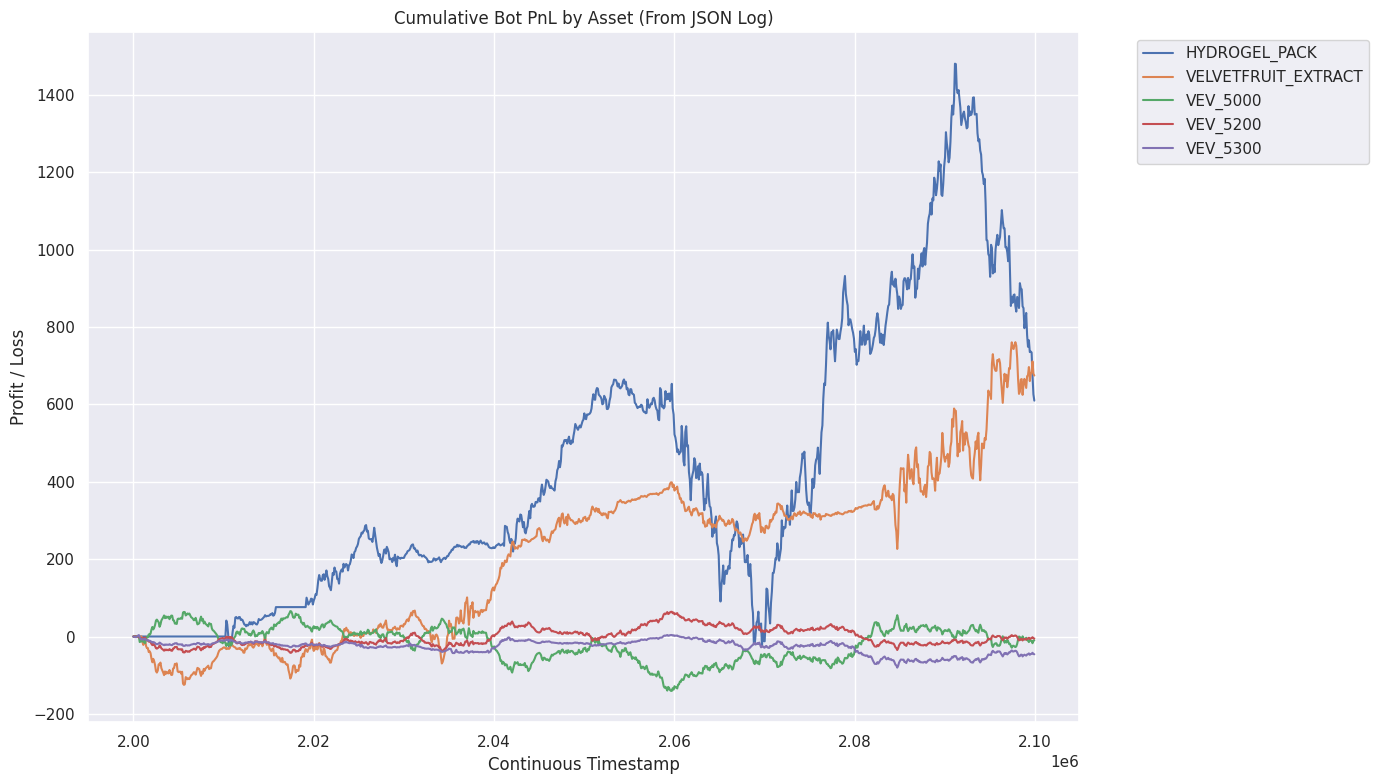

Final PnL Contribution by Asset:
product
VELVETFRUIT_EXTRACT    674.843750
HYDROGEL_PACK          609.843750
VEV_4000                 0.000000
VEV_4500                 0.000000
VEV_5100                 0.000000
VEV_6000                 0.000000
VEV_5500                 0.000000
VEV_5400                 0.000000
VEV_6500                 0.000000
VEV_5200                -5.216827
VEV_5000                -9.779297
VEV_5300               -45.943054
Name: 2099900, dtype: float64


In [19]:
import json
import io

# 1. Load the specific submission JSON
with open(logs_dir / 'sub4' / '407754.json', 'r') as f:
    submission_data = json.load(f)

# 2. Extract the activitiesLog which contains your specific bot's PnL
activities_csv = submission_data.get('activitiesLog', '')

bot_log = pd.read_csv(io.StringIO(activities_csv), sep=';')

# Create continuous time
bot_log['continuous_time'] = bot_log['timestamp'] + (bot_log['day'] * 1000000)

# Pivot and use the fixed ffill() method
pnl_data = bot_log.pivot(index='continuous_time', columns='product', values='profit_and_loss')
pnl_data = pnl_data.ffill().fillna(0)  # <-- Fixed pandas syntax here

# 3. Plotting
plt.figure(figsize=(14, 8))
for col in pnl_data.columns:
    # Only plot if the asset actually had PnL movement to keep the chart clean
    if pnl_data[col].iloc[-1] != 0 or pnl_data[col].min() < 0:
        plt.plot(pnl_data.index, pnl_data[col], label=col, linewidth=1.5)

plt.title('Cumulative Bot PnL by Asset (From JSON Log)')
plt.xlabel('Continuous Timestamp')
plt.ylabel('Profit / Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print final breakdown
print("Final PnL Contribution by Asset:")
print(pnl_data.iloc[-1].sort_values(ascending=False))

### Options Pricing & Vega Analysis

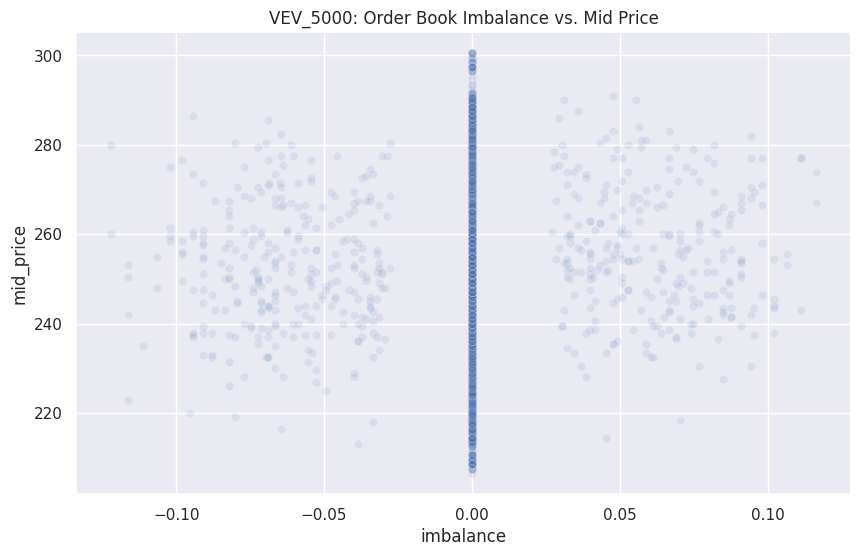

In [20]:
# Filter for VEV products
vev_prices = prices[prices['product'].str.startswith('VEV')].copy()

# Calculate order book imbalance (Bid Vol vs Ask Vol)
vev_prices['bid_vol_total'] = vev_prices['bid_volume_1'].fillna(0) + vev_prices['bid_volume_2'].fillna(0) + vev_prices['bid_volume_3'].fillna(0)
vev_prices['ask_vol_total'] = vev_prices['ask_volume_1'].fillna(0) + vev_prices['ask_volume_2'].fillna(0) + vev_prices['ask_volume_3'].fillna(0)

vev_prices['imbalance'] = (vev_prices['bid_vol_total'] - vev_prices['ask_vol_total']) / (vev_prices['bid_vol_total'] + vev_prices['ask_vol_total'])

# Plot correlation between imbalance and price shifts
plt.figure(figsize=(10, 6))
sns.scatterplot(data=vev_prices[vev_prices['product'] == 'VEV_5000'], x='imbalance', y='mid_price', alpha=0.1)
plt.title('VEV_5000: Order Book Imbalance vs. Mid Price')
plt.show()